## **Iris Flower Classification**

**Import Required Libraries**

In [2]:
# Import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

**Load the Dataset**

In [5]:
df = pd.read_csv('/content/sample_data/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**Understand the Dataset**

In [6]:
# Check dataset info
df.info()

# Check missing values
df.isnull().sum()

# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


**Dataset Features:**

SepalLengthCm

SepalWidthCm

PetalLengthCm

PetalWidthCm

Species (Target variable)

**The species are:**

Iris-setosa

Iris-versicolor

Iris-virginica

### **Data Visualization**


**Species Distribution**

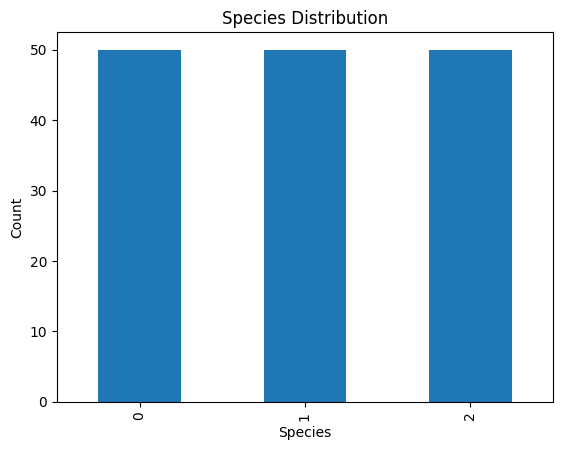

In [21]:
import matplotlib.pyplot as plt

# Count each species
species_count = df['Species'].value_counts()

# Bar Chart
plt.figure()
species_count.plot(kind='bar')
plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

**Sepal Length vs Petal Length by Species**

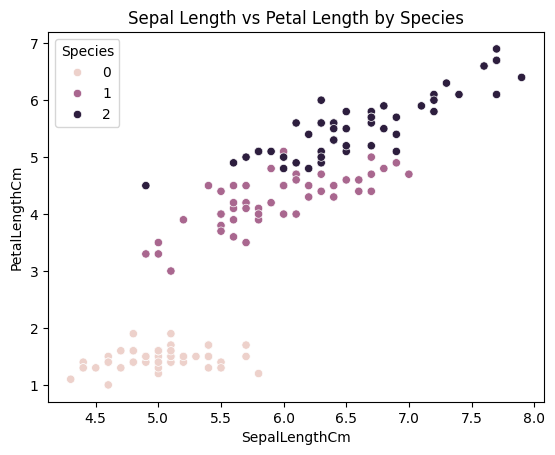

In [23]:
import seaborn as sns

plt.figure()
sns.scatterplot(x='SepalLengthCm', y='PetalLengthCm', hue='Species', data=df)

plt.title("Sepal Length vs Petal Length by Species")
plt.show()

**Data Preprocessing**

In [7]:
df = df.drop('Id', axis=1)
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**Split Data into Features and Target**

In [13]:
X = df.drop('Species', axis=1)
y = df['Species']

**Train-Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (120, 4)
Testing size: (30, 4)


**Train Machine Learning Models**

**Model 1: K-Nearest Neighbors (KNN)**

In [16]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 1.0


**Model 2: Decision Tree**

In [17]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


**Model 3: Random Forest**

In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


**Evaluate Model Performance**

**Classification Report**

In [19]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**It shows:**

1.   Precision
2.   Recall
3.   F1-score
4.   Accuracy






**Confusion Matrix**

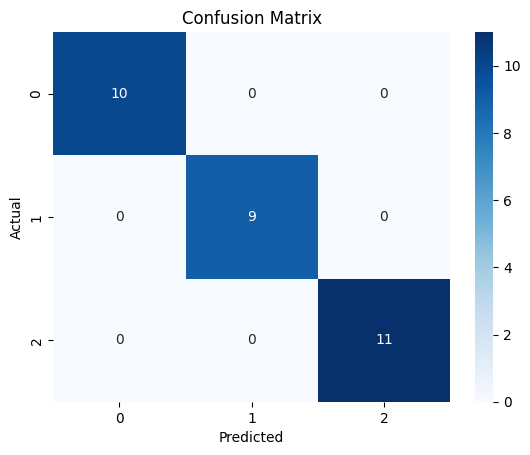

In [20]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Conclusion:**
In this project, I successfully developed a machine learning model to classify Iris flowers into three species using their sepal and petal measurements. I explored the dataset through visualization to better understand the relationship between features and species distribution before building the models. After preprocessing the data and splitting it into training and testing sets, I trained multiple classification algorithms using the Scikit-learn library. The models achieved very high accuracy on the test data, demonstrating that the features are highly effective in distinguishing between the three species. Through this project, I gained a clear understanding of supervised learning, classification techniques, model evaluation, and the importance of data visualization in machine learning. Overall, this project strengthened my practical knowledge of building and evaluating classification models.